In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
            ZForecaster, train_z_forecaster, plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
            plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params, _make_intra_window_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path


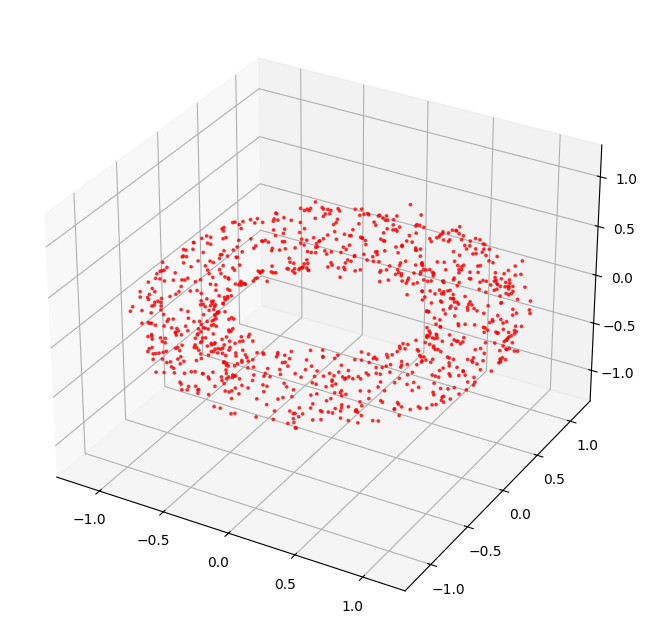

In [2]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [3]:
"persistence"

# persistence    = PersistencePlotter(max_dim=1)
# diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
# diagrams_clean = persistence.remove_inf(diagrams_list)
# entropy_array  = persistence.compute_entropy(diagrams_clean)
# persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
# betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

# print("Persistence array:", entropy_array)
# print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

# persistence.plot_persistence_diagrams(diagrams_list)
# persistence.plot_entropy(entropy_array)
# persistence.plot_persistence_image(persistence_images_list[1])  # H1
# persistence.plot_betti_curves(betti_curves_array)


'persistence'

In [4]:
"timedelay embeddings"

# x  = np.linspace(0, 14*np.pi, 1000)
# y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
# y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
# plt.figure()
# plt.plot(x, y1, label='y1')
# plt.plot(x, y2, label='y2')
# plt.legend()
# plt.show()

# min_len = min(len(y1), len(y2))
# y1, y2  = y1[:min_len], y2[:min_len]

# time_delay, lag_dim = 20, 4
# y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
# y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# # time_delay2, lag_dim2 = 20, 4
# y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
# y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
# plt.figure()
# # plt.scatter(y1_now, y1_delayed, s=4)
# plt.scatter(y2_now, y2_delayed, s=4)
# plt.show()

# # persistence stuff
# persistence  = PersistencePlotter(max_dim=1)
# n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
# y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# # y_data       = np.column_stack((y1_now, y1_delayed))
# diagrams_list = persistence.compute_persistence_diagrams(y_all)
# persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


'timedelay embeddings'

In [5]:
"⚽️ yaml params"
geo_params           = read_yaml_params(file_path="control_panel.yaml")

X_windowing_params   = geo_params["general"]["X_windowing"]
X_window_size        = X_windowing_params["window_size"]
X_stride_frac        = X_windowing_params["stride_frac"]

LSTMAE_params             = geo_params["general"]["LSTM_AE"]
lstmae_latent_dim         = LSTMAE_params["latent_dim"]
lstmae_encoder_hidden_dim = LSTMAE_params["encoder_hidden_dim"]
lstmae_decoder_hidden_dim = LSTMAE_params["decoder_hidden_dim"]
lstmae_patience           = LSTMAE_params["patience"]
lstm_ae_epochs            = LSTMAE_params["epochs"]
lstmae_learning_rate      = LSTMAE_params["learning_rate"]

z_windowing_params   = geo_params["general"]["z_windowing"]
z_window_frac        = z_windowing_params["z_window_frac"]
z_stride_frac        = z_windowing_params["z_stride_frac"]

z_forecaster_params  = geo_params["general"]["z_forecaster"]
H_forecaster         = z_forecaster_params["H"]
hidden_dim_forecaster= z_forecaster_params["hidden_dim"]
forecaster_epochs    = z_forecaster_params["epochs"]
forecaster_patience  = z_forecaster_params["earlystop_patience"]
forecaster_lr        = z_forecaster_params["lr"]
forecaster_batch_size= z_forecaster_params["batch_size"]

persistence_params = geo_params["general"]["persistence"]
max_dim            = persistence_params["max_dim"]
pixel_size         = persistence_params["pixel_size"]

topo_model_params  = geo_params["general"]["topo_model"]
topo_every         = topo_model_params["topo_every"]
hidden_dim         = topo_model_params["hidden_dim"]
epochs_topo        = topo_model_params["epochs"]
topo_batch_size    = topo_model_params["batch_size"]
lr_topo            = topo_model_params["lr"]
lambda_topo        = topo_model_params["lambda_topo"]
N_runs             = topo_model_params["N_runs"]


In [ ]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 10_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = np.sin(timesteps) * ((0.5+0.5*timesteps) * np.sin(2*timesteps + 1)) + 0.03 * rng.normal(size=timesteps.shape)
# X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X1 = np.sin(timesteps) + np.sin(0.1* timesteps**2) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(1.7 * timesteps + X1) + 0.03 * rng.normal(size=timesteps.shape)
X3 = np.sin(X2 * X1) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2, X3))

X_stride        = X_window_size//X_stride_frac
X_windows       = window_2d_sequence_to_3d(X, X_window_size, X_stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)


In [7]:
# "⚽️ real dataset"

# import sys
# sys.path.append('../..')
# from src.preprocessing.data_loader_module import DatasetLoading

# dataset_loader_obj = DatasetLoading()
# X_all, y_all = dataset_loader_obj.load_beijing_data()

# # 1. split first (important)
# X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# # 2. reshape to 2D
# N, T, F    = X_train.shape
# X_train_2d = X_train.reshape(-1, F)
# X_test_2d  = X_test.reshape(-1, F)

# # 3. fit scaler on train only
# scaler         = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_2d)
# X_test_scaled  = scaler.transform(X_test_2d)

# # 4. reshape back to 3D
# X_train = X_train_scaled.reshape(N, T, F)
# X_test  = X_test_scaled.reshape(X_test.shape[0], T, F)
# print(X_train.shape, X_test.shape)



X shape (10000, 3)
X_windows shape: (393, 200, 3)
X_train/test shape: (314, 200, 3) (79, 200, 3)


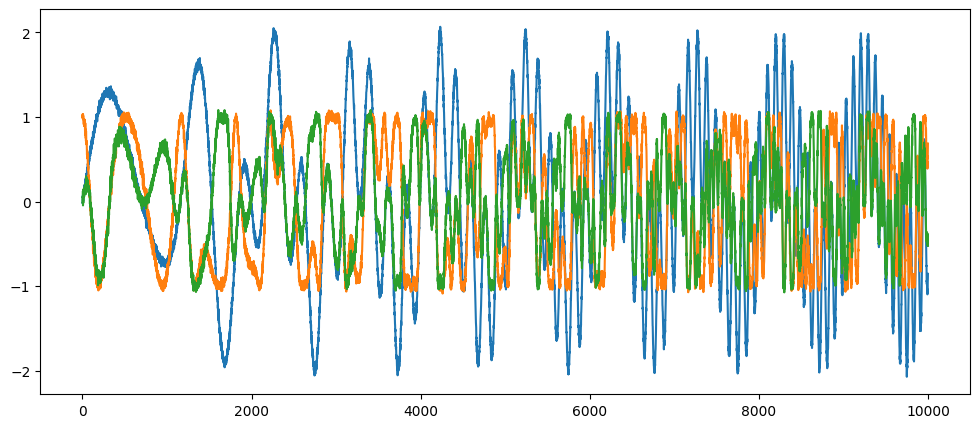

In [8]:
"⚽️ data processing"
# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape)
print("X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


Epoch 20/100, Loss: 0.0127
Epoch 40/100, Loss: 0.0085
Epoch 60/100, Loss: 0.0057
Epoch 80/100, Loss: 0.0025
Epoch 100/100, Loss: 0.0010
z_train shape: torch.Size([314, 200, 8]) z_test shape: torch.Size([79, 200, 8])


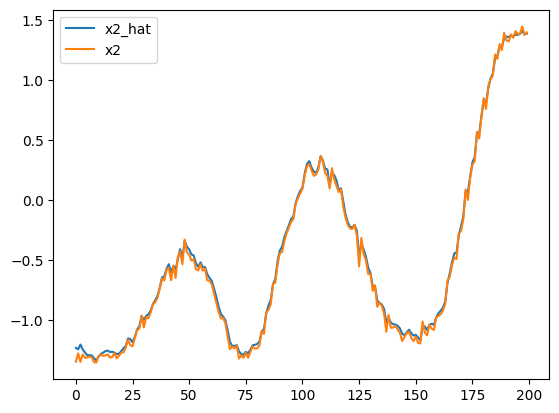

In [9]:
"⚽️ LSTM encoder: train + eval"

X_train, X_test  = numpy_to_torch(X_train), numpy_to_torch(X_test)
input_dim        = X_train.shape[-1]
lstm_ae          = LSTMAutoencoder(input_dim, latent_dim=lstmae_latent_dim, encoder_hidden_dim=lstmae_encoder_hidden_dim,
                             decoder_hidden_dim=lstmae_decoder_hidden_dim, epochs=lstm_ae_epochs, learning_rate=lstmae_learning_rate)
losses           = lstm_ae.train_model(X_train, patience=lstmae_patience)
device           = lstm_ae.device

# inference:
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

#scale z while staying on torch
mean    = z_train.mean(dim=0)
std     = z_train.std(dim=0) + 1e-8
z_train = (z_train - mean) / std
z_test  = (z_test - mean) / std

print("z_train shape:", z_train.shape, "z_test shape:", z_test.shape)

# visual test that encoder works on x_test
window_number, feature_number = 2, 1
plt.plot(x_test_hat[window_number, :, feature_number].cpu(), label=f'x{window_number}_hat')
plt.plot(X_test[window_number, :, feature_number].cpu(), label=f'x{window_number}')
plt.legend()
plt.show()


Text(0.5, 1.0, 'LSTM AE Latent Space')

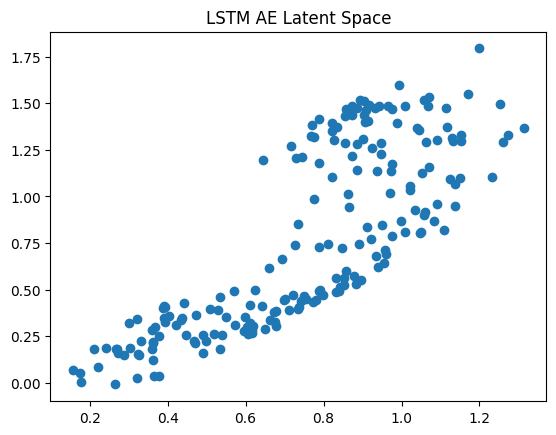

In [10]:
plt.scatter(z_train[0, :, 0].cpu(), z_train[0, :, 1].cpu(), label='Latent Dim 1')
plt.title('LSTM AE Latent Space')

z_train=torch.Size([314, 200, 8]), z_test=torch.Size([79, 200, 8])
Plotting features for window 1 (dataset shape: torch.Size([314, 200, 8]))


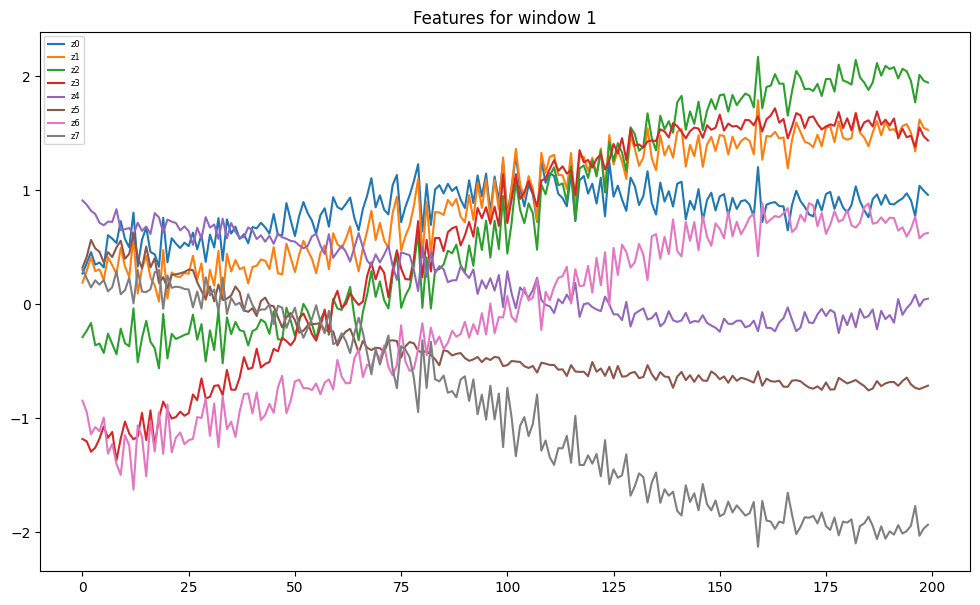

In [11]:
"⚽️ windowing latents z"

# actual_z_win_size = int(len(z_train) * z_window_frac)
# actual_z_stride   = int(len(z_train) * z_stride_frac)
# z_train_windows   = window_2d_sequence_to_3d(z_train, actual_z_win_size, actual_z_stride)
# z_test_windows    = window_2d_sequence_to_3d(z_test,  actual_z_win_size, actual_z_stride)

print(f"z_train={z_train.shape}, z_test={z_test.shape}")
# print(f"z_train_win= {z_train_windows.shape}, z_test_win= {z_test_windows.shape}")
plot_all_features_in_2d_array(z_train, window_number=1)
# plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)


epoch 10 loss 0.0469
epoch 20 loss 0.0272
epoch 30 loss 0.0258
epoch 40 loss 0.0228
epoch 50 loss 0.0220
Test MSE: 0.0304
Z_hat_test: torch.Size([79, 199, 8]), y_test: torch.Size([79, 199, 8])


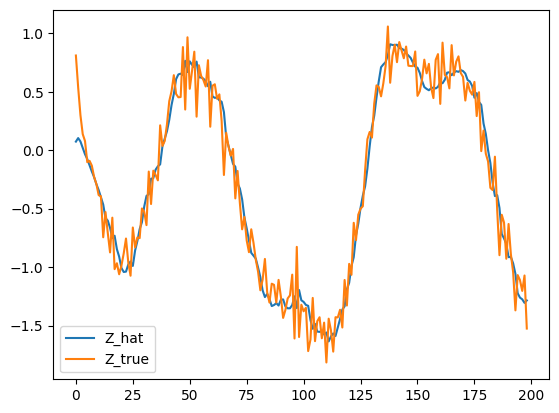

In [ ]:
"⚽️ forecasting z (intra-window)"

# --- build intra-window dataset ---
# ⚠️ this function is also in the py module, need to remove 1 of them
def make_intra_window_dataset(z: torch.Tensor, H: int):
    """Shift inside each window: predict z[t+H] from z[t]"""
    return z[:, :-H, :], z[:, H:, :]

x_train, y_train = make_intra_window_dataset(z_train, H_forecaster)
x_test,  y_test  = make_intra_window_dataset(z_test,  H_forecaster)

x_train = x_train.float()
y_train = y_train.float()
x_test  = x_test.float()
y_test  = y_test.float()

# --- model ---
input_dim = z_train.shape[-1]
model = ZForecaster(input_dim=input_dim, hidden_dim=hidden_dim_forecaster).to(device)

# --- train ---
z_mse = train_z_forecaster(
    model,
    z_train=z_train,
    z_test=z_test,
    H=H_forecaster,
    epochs=forecaster_epochs,
    lr= forecaster_lr,
    batch_size= forecaster_batch_size,)
print(f"Test MSE: {z_mse:.4f}")

# --- eval ---
model.eval()
with torch.no_grad():
    Z_hat_test = model(x_test.to(device)).cpu()   # (B, T-H, d)

print(f"Z_hat_test: {Z_hat_test.shape}, y_test: {y_test.shape}")

# --- plot (single window, single dim) ---
plt.plot(Z_hat_test[0, :, 1].cpu(), label='Z_hat')
plt.plot(y_test[0, :, 1].cpu(), label='Z_true')
plt.legend()
plt.show()

In [13]:
"⚠️ moved takens stuff temporarily here"

# takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
# z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
# z_test_takens  = takens_obj.make_timedelay_embeddings_grid(z_test_windows)
# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

# print(f"z_win_takens= {z_train_takens.shape}")

# plotter.plot_persistence_diagrams(dgms)

# # A(t) = mean_k corr(z[:,k], z[:,k+τ]) # acf decides the best window size

# window = 2
# plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
# plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

'⚠️ moved takens stuff temporarily here'

In [14]:
# "⚠️⚽️ persistence + d_wasserstein + plotting"
# # TODO: is this cell really needed?

# plotter = PersistencePlotter(max_dim=2, pixel_size=0.2)
# d_wasser_obj = WassersteinDistance

# # ALIGNMENT FIX (⚠️ when H != 1, need to fix the [1:] bit in the next 4 lines)
# z_true_test = z_test_windows[1:]   # (9, 100, 8)
# z_hat_test  = Z_hat_test           # (9, 100, 8)

# z_true_train = z_train_windows[1:]
# z_hat_train  = Z_hat_train

# print("train aligned:", z_true_train.shape, z_hat_train.shape)
# print("test aligned :", z_true_test.shape, z_hat_test.shape)

# # PERSISTENCE FEATURES
# true_betti_train = plotter.compute_persistence_features(z_true_train, mode="betti")
# hat_betti_train  = plotter.compute_persistence_features(z_hat_train, mode="betti")

# true_betti_test = plotter.compute_persistence_features(z_true_test, mode="betti")
# hat_betti_test  = plotter.compute_persistence_features(z_hat_test, mode="betti")

# # TOPOLOGY LOSS (WASSERSTEIN)
# betti_dist_train = d_wasser_obj.compute_wasserstein_distance(true_betti_train, hat_betti_train, delay=1)
# betti_dist_test  = d_wasser_obj.compute_wasserstein_distance(true_betti_test, hat_betti_test, delay=1)

# # OUTPUT SHAPES + SUMMARY
# print("train betti dist shape:", betti_dist_train.shape)
# print("test betti dist shape :", betti_dist_test.shape)

# print("train mean topo error:", betti_dist_train.mean().item())
# print("test mean topo error :", betti_dist_test.mean().item())

# # ==============
# # X_hat, non-Takens

# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(Z_hat_train[0]))
# # z_betti_train    = plotter.compute_persistence_features(Z_hat_train, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(Z_hat_train, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(Z_hat_train, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(Z_hat_train, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(Z_hat_test, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(Z_hat_test, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(Z_hat_test, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(Z_hat_test, mode="landscape")

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)

# # ===============
# # Takens

# # z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(z_test_takens, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(z_test_takens, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(z_test_takens, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(z_test_takens, mode="landscape")

# # print("betti features shape:", z_betti_train.shape)
# # plotter.plot_persistence_grid(z_train_windows)
# # plotter.plot_persistence_image_grid(z_train_windows)
# # plotter.plot_betti_grid(z_train_windows)
# # plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)


In [15]:
# "[BAD] waasserstein as exog. feature to z"
# from torchmetrics.regression import R2Score

# # CONFIG
# USE_EXOGENOUS = 0
# EXOG_FEATURES = ["betti"]
# N_RUNS = 8
# EPOCHS = 100
# H      = 1 # prediction horizon

# print(f"Using exogenous: {USE_EXOGENOUS} | Features: {EXOG_FEATURES} | Runs: {N_RUNS}")

# exog_map = {
#     "betti": {"train": betti_dist_train, "test": betti_dist_test},
#     "image": {"train": image_dist_train, "test": image_dist_test},
#     "diagram": {"train": diagram_dist_train, "test": diagram_dist_test},
#     "landscape": {"train": landscape_dist_train, "test": landscape_dist_test}}

# def build_sequences(z: torch.Tensor, H: int):
#     """Create (x, y) sequences from z. y = next H steps of last latent dim, x = all latent dims except last, aligned with y."""
#     idx = torch.arange(len(z)-H)
#     x   = z[:-H]
#     y   = torch.stack([z[i+1:i+H+1, -1, :] for i in idx])
#     return x, y, idx

# z_train_t = torch.tensor(z_train_takens, dtype=torch.float32, device=device)
# z_test_t  = torch.tensor(z_test_takens,  dtype=torch.float32, device=device)

# x_train, y_train, idx_train = build_sequences(z_train_t, H)
# x_test, y_test, idx_test    = build_sequences(z_test_t, H)

# n_rows = x_train.shape[1]
# n_cols = x_train.shape[2]

# print(f"b4 adding exogenous features, x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

# def add_exogenous_features_to_X(X_train, X_test, idx_train, idx_test, exog_map, feature_names, device):
#     """Adds exogenous features to input X_train/X_test tensors based on the provided exog_map and EXOG_FEATURES list
#     if USE_EXOGENOUS = False, returns original X_train/X_test without modification
#     if USE_EXOGENOUS = True, concats exogenous features to X_train/X_test along the feature dim"""
#     exog_train_list, exog_test_list = [], []

#     T = X_train.shape[1]

#     for name in feature_names:
#             train_full = torch.tensor(exog_map[name]["train"], dtype=torch.float32, device=device)
#             test_full  = torch.tensor(exog_map[name]["test"], dtype=torch.float32, device=device)

#             # Use the indices from build_sequences to align the data
#             train = train_full[idx_train]
#             test  = test_full[idx_test]

#             # Reshape to (Batch, Time, 1) to match X_train/X_test
#             train = train[:, None, None].expand(-1, X_train.shape[1], 1)
#             test  = test[:, None, None].expand(-1, X_test.shape[1], 1)

#             exog_train_list.append(train)
#             exog_test_list.append(test)

#     exog_train = torch.cat(exog_train_list, dim=-1)
#     exog_test  = torch.cat(exog_test_list, dim=-1)

#     mean = exog_train.mean()
#     std = exog_train.std().clamp_min(1e-8)

#     exog_train = (exog_train - mean) / std
#     exog_test  = (exog_test - mean) / std

#     return torch.cat([X_train, exog_train], dim=-1), torch.cat([X_test, exog_test], dim=-1)

# if USE_EXOGENOUS:
#     x_train, x_test = add_exogenous_features_to_X(x_train, x_test, idx_train, idx_test, exog_map, EXOG_FEATURES, device=device)

# print(f"After adding exogenous features, x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

# input_dim = x_train.shape[-1]

# print("x_train:", x_train.shape)
# print("exog train:", exog_map[EXOG_FEATURES[0]]["train"].shape)
# print("Train:", x_train.shape, y_train.shape)
# print("Test :", x_test.shape,  y_test.shape)

# mean_mse, std_mse, mean_r2, std_r2 = ZForecaster.train_eval_forecaster(
#     x_train, y_train,
#     x_test, y_test,
#     input_dim=input_dim,
#     n_cols=n_cols,
#     H=H,
#     device=device,
#     n_runs=N_RUNS,
#     epochs=EPOCHS)

# results_line = (f"{EXOG_FEATURES=}, " if USE_EXOGENOUS else "NO EXOGENOUS FEATURES, ") + f"H={H}, MSE: {mean_mse:.4f}±{std_mse:.4f}, R²: {mean_r2:.4f}±{std_r2:.4f}\n"

# print("\n" + results_line)
# write_results_to_file(file="results.txt", line=results_line)


In [ ]:
"🎯⚽️ models"

def _train_epoch(model, loader, opt, mse, device, lambda_topo=0.0, plotter=None, wasser=None, topo_every=5, persistence_mode="betti"):
    """1 epoch trainer. Persistence attribute can be set (image, betti, diagram, landscape)"""
    model.train()
    total_loss = 0.0

    for step, (xb, yb) in enumerate(loader):
        xb, yb    = xb.to(device), yb.to(device)
        z_pred    = model(xb)
        loss_dyn  = mse(z_pred, yb)
        loss_topo = torch.tensor(0.0, device=device)

        if plotter is not None and wasser is not None and step % topo_every == 0:
            z_true_np = yb.detach().cpu().numpy()
            z_pred_np = z_pred.detach().cpu().numpy()

            true_feat = plotter.compute_persistence_features(z_true_np, mode=persistence_mode)
            pred_feat = plotter.compute_persistence_features(z_pred_np, mode=persistence_mode)

            if len(true_feat) and len(pred_feat):
                val       = wasser.compute_wasserstein_distance(true_feat, pred_feat, delay=1).mean()
                loss_topo = torch.tensor(val, device=device)
                print(f"step {step} | dyn {loss_dyn.item():.4f} | topo {loss_topo.item():.4f}")

        loss = loss_dyn + lambda_topo * loss_topo
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def train_latent_forecaster(z, plotter, wasser, device, input_dim,
                           hidden_dim=64, epochs=20, batch_size=32,
                           lr=1e-3, lambda_topo=0.05, topo_every=5, H=1, persistence_mode="betti"):
    """Train latent forecaster on intra-window dynamics."""
    x, y = make_intra_window_dataset(z, H)

    loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)
    model  = ZForecaster(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr)
    mse    = torch.nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        epoch_loss = _train_epoch(
            model, loader, opt, mse, device,
            lambda_topo=lambda_topo,
            plotter=plotter,
            wasser=wasser,
            topo_every=topo_every,
            persistence_mode=persistence_mode)
        losses.append(epoch_loss)

        # if epoch % 3 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch}: {epoch_loss:.4f}")
    return model, losses


def save_model(model, path: str):
    """Save model weights."""
    torch.save(model.state_dict(), path)

def load_model(path: str, input_dim: int, hidden_dim: int, device):
    """Reload trained model."""
    model = ZForecaster(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

device  = lstm_ae.device
plotter = PersistencePlotter(max_dim=max_dim, pixel_size=pixel_size)
wasser  = WassersteinDistance()

model_pt_name = Path(f"models/latent_forecaster_exog_H{H_forecaster}.pt")

# lets just run from the next cell
# if 1>2:#model_pt_name.exists():
#     topo_model = load_model(model_pt_name, input_dim=input_dim, hidden_dim=hidden_dim, device=device)
#     print(f"Model loaded from {model_pt_name}")
# else:
#     topo_model, losses = train_latent_forecaster(z_train_windows, plotter=plotter, wasser=wasser, device=device,
#                                                  input_dim=z_train.shape[-1], topo_every=topo_every, lambda_topo=lambda_topo,
#                                                  hidden_dim=hidden_dim, epochs=epochs_topo, lr=lr_topo, batch_size=batch_size,
#                                                  H = H_forecaster)
#     save_model(topo_model, model_pt_name)
#     print(f"Model saved to {model_pt_name}")


In [17]:
"⚽️ results + comparisons"
from torchmetrics.regression import R2Score
from sklearn.linear_model import LinearRegression

def compute_r2(pred, true, device):
    r2 = R2Score().to(device)
    p  = pred.reshape(-1, pred.shape[-1]).to(device)
    t  = true.reshape(-1, true.shape[-1]).to(device)
    return r2(p, t).item()

def compute_linear_baseline(z_train_win, z_test_win, H):
    """Computes Linear Regression baseline on flattened windows."""
    # Flatten: (num_windows, time, dim) -> (num_windows, time * dim)
    X_train_flat = z_train_win[:-H].reshape(z_train_win.shape[0]-H, -1).cpu().numpy()
    Y_train_flat = z_train_win[H:].reshape(z_train_win.shape[0]-H, -1).cpu().numpy()
    
    X_test_flat = z_test_win[:-H].reshape(z_test_win.shape[0]-H, -1).cpu().numpy()
    Y_test_real = z_test_win[H:].cpu().numpy() # Keep 3D for MSE

    # Train Linear Model
    reg = LinearRegression().fit(X_train_flat, Y_train_flat)
    
    # Predict
    Y_pred_flat = reg.predict(X_test_flat)
    Y_pred = Y_pred_flat.reshape(z_test_win.shape[0]-H, z_test_win.shape[1], z_test_win.shape[2])
    
    mse_linear = np.mean((Y_pred - Y_test_real)**2)
    return mse_linear, Y_pred

def evaluate_run(model, z_test_windows, H, device):
    model.eval()
    with torch.no_grad():
        z_test_in = z_test_windows[:-H].to(device)
        z_true    = z_test_windows[H:].cpu()
        z_naive   = z_test_windows[:-H].cpu()
        z_pred    = model(z_test_in).cpu()

        mse_model = ((z_pred - z_true) ** 2).mean().item()
        mse_naive = ((z_naive - z_true) ** 2).mean().item() #compute once is enough (it doesnt change)
        r2_model  = compute_r2(z_pred, z_true, device)
        r2_naive  = compute_r2(z_naive, z_true, device)

        pct_improvement = ((mse_naive - mse_model)/ mse_naive) * 100
        return mse_model, r2_model, mse_naive, r2_naive, pct_improvement

# --- THE STOCHASTIC LOOP ---
results_storage = [] # Storing as list of dicts for easier handling

print(f"🚀 Starting {N_runs} runs for H={H_forecaster}...")

for i in range(N_runs):
    topo_model, _ = train_latent_forecaster(
        z=z_train, plotter=plotter, wasser=wasser, device=device,
        input_dim=z_train.shape[-1], topo_every=topo_every, lambda_topo=lambda_topo,
        hidden_dim=hidden_dim, epochs=epochs_topo, lr=lr_topo, batch_size=topo_batch_size,
        H=H_forecaster)
    
    # Evaluate
    # metrics = evaluate_run(topo_model, z_test_windows, H_forecaster, device)
    metrics = evaluate_run(topo_model, z_test, H_forecaster, device)
    results_storage.append(metrics)
    # mse_linear, Y_pred_lin = compute_linear_baseline(z_train_windows, z_test_windows, H_forecaster)
    mse_linear, Y_pred_lin = compute_linear_baseline(z_train, z_test, H_forecaster)
    print(f"Run {i+1}/{N_runs} - MSE: {metrics[0]:.3f}, Improv: {metrics[4]:.2f}%")

res_arr           = np.array(results_storage)
mean_mse, std_mse = res_arr[:, 0].mean(), res_arr[:, 0].std()
mean_r2, std_r2   = res_arr[:, 1].mean(), res_arr[:, 1].std()
mean_naive_mse    = res_arr[:, 2].mean()
mean_naive_r2     = res_arr[:, 3].mean()
mean_pct_improv   = res_arr[:, 4].mean()

# Save to file
results_line = f"H={H_forecaster}, MSE: (Model={mean_mse:.2f}±{std_mse:.2f} LinReg={mse_linear:.2f} Naive={mean_naive_mse:.2f}) (Δ={mean_pct_improv:.1f}%), R²: ({mean_r2:.3f}±{std_r2:.3f}, Naive={mean_naive_r2:.3f}) \n"
write_results_to_file(file="results.txt", line=results_line)


🚀 Starting 1 runs for H=1...
step 0 | dyn 1.0291 | topo 12.2121
step 30 | dyn 1.4437 | topo 13.4104
epoch 0: 0.1922
step 0 | dyn 1.0742 | topo 11.1575
step 30 | dyn 0.7757 | topo 6.9946
epoch 1: 0.1361
step 0 | dyn 0.8279 | topo 10.1833
step 30 | dyn 0.7808 | topo 8.4100
epoch 2: 0.1395
step 0 | dyn 1.0303 | topo 13.4483
step 30 | dyn 1.1334 | topo 9.2479
epoch 3: 0.1702
step 0 | dyn 1.0870 | topo 8.1350
step 30 | dyn 1.1520 | topo 9.4742
epoch 4: 0.1321
step 0 | dyn 0.9804 | topo 11.1050
step 30 | dyn 1.0880 | topo 8.1871
epoch 5: 0.1447
step 0 | dyn 0.7941 | topo 11.3854
step 30 | dyn 0.9574 | topo 10.8546
epoch 6: 0.1668
step 0 | dyn 1.1167 | topo 10.7750
step 30 | dyn 1.0756 | topo 11.8346
epoch 7: 0.1696
step 0 | dyn 0.9437 | topo 9.7025
step 30 | dyn 0.9194 | topo 8.4083
epoch 8: 0.1358
step 0 | dyn 1.3241 | topo 8.9042
step 30 | dyn 1.0480 | topo 14.1854
epoch 9: 0.1732
step 0 | dyn 1.3824 | topo 13.3192
step 30 | dyn 1.1648 | topo 9.4879
epoch 10: 0.1711
step 0 | dyn 0.9715 | t

In [18]:
plt.scatter(z_true[:,0], z_true[:,1])
plt.scatter(z_pred[:,0], z_pred[:,1])

NameError: name 'z_true' is not defined